# 📊 End-to-End Data Preparation, Clustering & Classification
**Course:** ESPRIT — 4CCE9 (2026–2027)  
**Dataset:** Adult Census Income (UCI Machine Learning Repository)  
**Methodology:** CRISP-DM (Cross-Industry Standard Process for Data Mining)  
**Target Variable:** `income` (`<=50K` vs `>50K`)

---

## 1. Business Understanding

### 1.1 Context & Problem Formulation
Predicting an individual's earning capacity based on demographic, occupational, and educational parameters is a core problem in computational economics, financial credit scoring, and government policy planning. The **Adult Census Income dataset** (extracted from the 1994 U.S. Census Bureau database by Ronny Kohavi & Barry Becker) frames this as a binary classification challenge:
> **Objective:** Predict whether an individual's annual income exceeds $50,000.

### 1.2 Practical Business Applications
1. **Credit Risk & Loan Pre-Approval:** Allows automated financial underwriting without requiring immediate tax audit disclosures.
2. **Public Policy & Wage Disparity Research:** Dissects the quantitative relationship between education, working hours, demographic factors, and income thresholds.
3. **Targeted Wealth Marketing:** Enables institutions to direct wealth management and premium services to high-earning brackets.

### 1.3 Asymmetric Error Costs & Metric Justification
- **False Positive (Type I Error):** Model predicts `>50K`, but the true income is `<=50K`. (Consequence: Granting a loan or credit limit beyond the applicant's repayment ability $\rightarrow$ high default risk).
- **False Negative (Type II Error):** Model predicts `<=50K`, but the true income is `>50K`. (Consequence: Sub-optimal marketing targeting / minor lost opportunity).
- **Metric Choice:** Because the dataset has ~76% `<=50K` and ~24% `>50K`, standard **Accuracy is misleading** (a naive model predicting `<=50K` for everyone achieves ~76% accuracy while catching 0% of high earners). We prioritize **ROC-AUC, Precision-Recall AUC (PR-AUC), and F1-Score**.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Preprocessing & Clustering
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import (
    silhouette_score, roc_auc_score, f1_score, precision_score, 
    recall_score, accuracy_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

# Supervised Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("✅ All required libraries imported successfully!")


✅ All required libraries imported successfully!


---
## 2. Data Understanding & Acquisition

We load both the training split (`adult.data`, 32,561 rows) and test split (`adult.test`, 16,281 rows).
**Key Considerations:**
- Column headers are missing in the raw text and must be assigned from `adult.names`.
- Leading whitespace after commas must be stripped (`skipinitialspace=True`).
- Line 1 of `adult.test` contains a cross-validation comment (`|1x3 Cross validator`), requiring `skiprows=1`.


In [2]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

train_path = '../data/raw/adult.data'
test_path  = '../data/raw/adult.test'

# Load raw splits
df_train = pd.read_csv(train_path, header=None, names=columns, skipinitialspace=True)
df_test  = pd.read_csv(test_path,  header=None, names=columns, skipinitialspace=True, skiprows=1)

print(f"Training set shape: {df_train.shape}")
print(f"Test set shape:     {df_test.shape}")
print(f"Total observations: {len(df_train) + len(df_test)}")

df_train.head()


Training set shape: (32561, 15)
Test set shape:     (16281, 15)
Total observations: 48842


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


---
### 2.1 Unmasking Data Quality Issues & Traps

We immediately inspect:
1. **Target String Inconsistency:** UCI added a trailing dot `.` to labels in `adult.test` (`<=50K.` vs `<=50K`).
2. **Hidden Missing Values (`?`):** Missing entries were encoded as literal `'?'` characters, escaping standard `.isnull()` checks.
3. **Exact Duplicates:** Identifying identical participant responses.


In [3]:
# 1. Target Label Comparison
print("=== TARGET VALUE COUNTS (Train) ===")
print(df_train['income'].value_counts())
print("\n=== TARGET VALUE COUNTS (Test) ===")
print(df_test['income'].value_counts())

# 2. Inspecting Hidden Missing Values ('?')
print("\n=== FEATURES WITH '?' ENCODED VALUES (Train) ===")
missing_stats = []
for col in df_train.columns:
    q_count = (df_train[col] == '?').sum()
    if q_count > 0:
        missing_stats.append({
            'Feature': col,
            'Missing_Count': q_count,
            'Percentage': round((q_count / len(df_train)) * 100, 2)
        })

df_missing = pd.DataFrame(missing_stats)
display(df_missing)

# 3. Duplicate Records
print(f"\nDuplicate rows in Train: {df_train.duplicated().sum()}")
print(f"Duplicate rows in Test:  {df_test.duplicated().sum()}")


=== TARGET VALUE COUNTS (Train) ===
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

=== TARGET VALUE COUNTS (Test) ===
income
<=50K.    12435
>50K.      3846
Name: count, dtype: int64

=== FEATURES WITH '?' ENCODED VALUES (Train) ===


,Feature,Missing_Count,Percentage
0,workclass,1836,5.64
1,occupation,1843,5.66
2,native_country,583,1.79



Duplicate rows in Train: 24
Duplicate rows in Test:  5


---
## 3. Exploratory Data Analysis (EDA) & Visualizations

We now systematically analyze:
- **Target Distribution & Imbalance**
- **Age Distribution by Income Level**
- **Education Level & Educational Attainment (`education_num`) vs Income**
- **Working Hours (`hours_per_week`) vs Income**
- **Extreme Skewness in `capital_gain` and `capital_loss`**


C:\Users\mehdi\AppData\Local\Temp\ipykernel_30972\797889661.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='income', ax=axes[0], palette=['#4A90E2', '#E74C3C'])


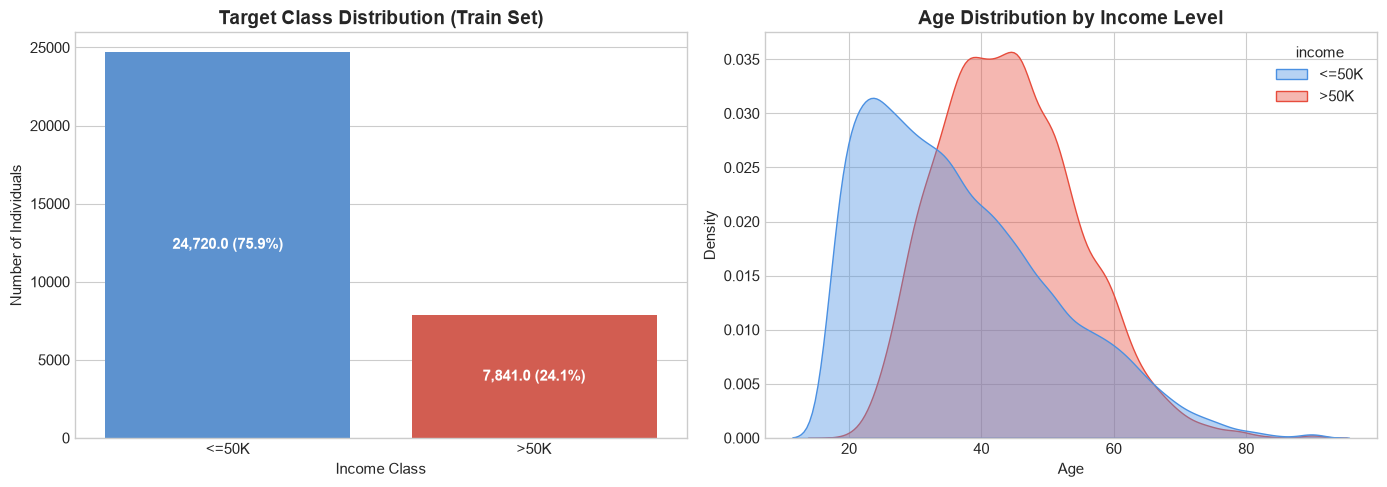

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Target Class Imbalance
sns.countplot(data=df_train, x='income', ax=axes[0], palette=['#4A90E2', '#E74C3C'])
axes[0].set_title('Target Class Distribution (Train Set)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Income Class')
axes[0].set_ylabel('Number of Individuals')
total = len(df_train)
for p in axes[0].patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    axes[0].annotate(f"{p.get_height():,} ({pct})", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

# Plot 2: Age vs Income KDE
sns.kdeplot(data=df_train, x='age', hue='income', common_norm=False, fill=True, ax=axes[1], palette=['#4A90E2', '#E74C3C'], alpha=0.4)
axes[1].set_title('Age Distribution by Income Level', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()


C:\Users\mehdi\AppData\Local\Temp\ipykernel_30972\321156976.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='income', y='hours_per_week', ax=axes[1], palette=['#4A90E2', '#E74C3C'])


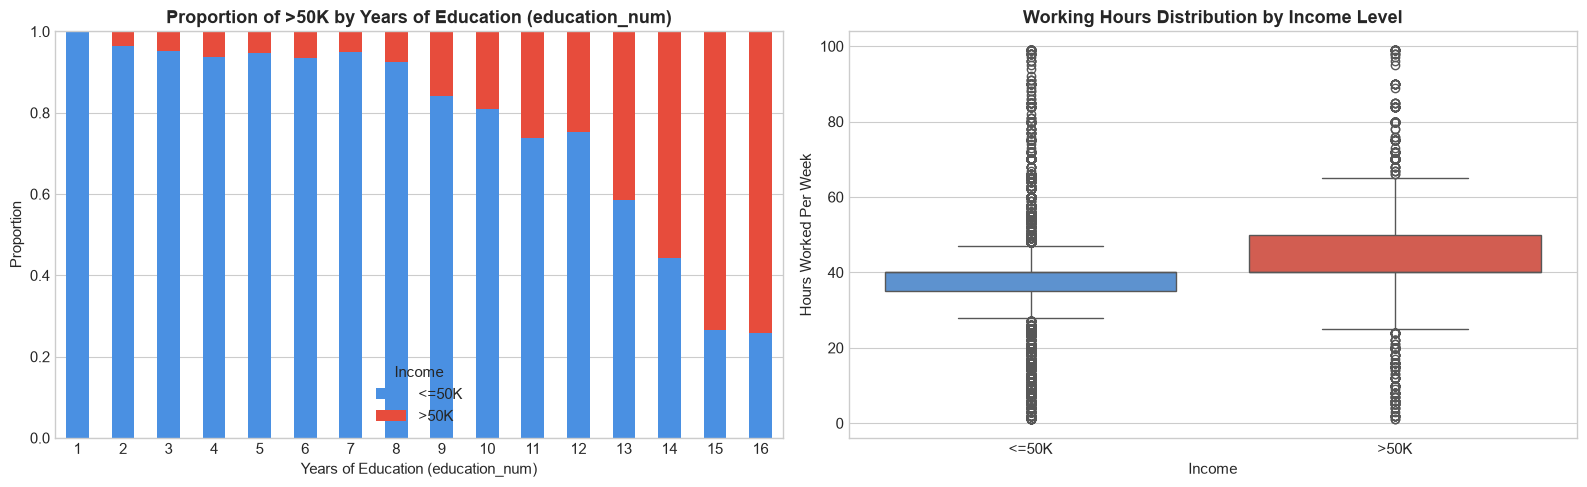

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 3: Education Years vs Income Proportion
edu_income = pd.crosstab(df_train['education_num'], df_train['income'], normalize='index')
edu_income.plot(kind='bar', stacked=True, ax=axes[0], color=['#4A90E2', '#E74C3C'])
axes[0].set_title('Proportion of >50K by Years of Education (education_num)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Years of Education (education_num)')
axes[0].set_ylabel('Proportion')
axes[0].legend(title='Income')
axes[0].tick_params(axis='x', rotation=0)

# Plot 4: Hours Per Week vs Income
sns.boxplot(data=df_train, x='income', y='hours_per_week', ax=axes[1], palette=['#4A90E2', '#E74C3C'])
axes[1].set_title('Working Hours Distribution by Income Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Hours Worked Per Week')

plt.tight_layout()
plt.show()


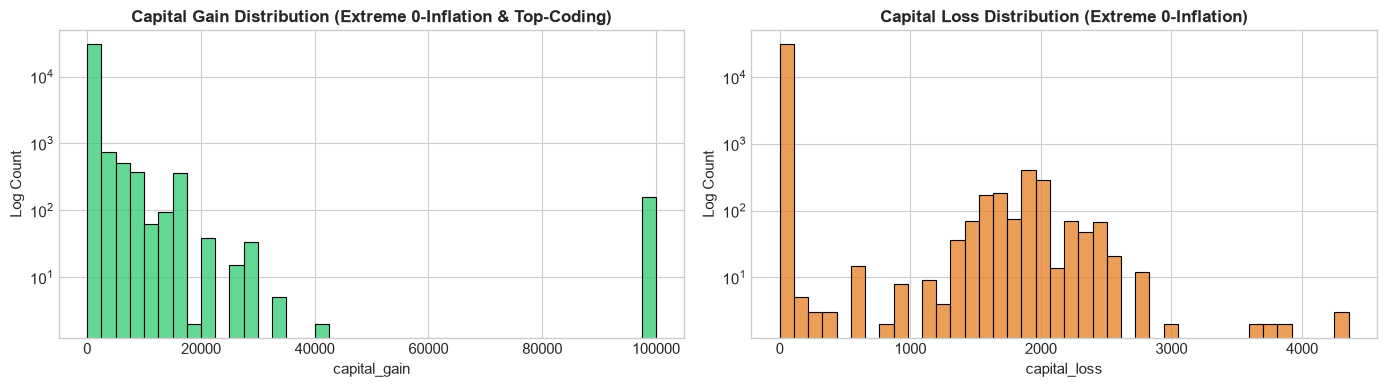

Capital Gain Skewness: 11.95
Capital Loss Skewness: 4.59
Percentage of 0s in capital_gain: 91.67%
Percentage of 0s in capital_loss: 95.33%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Capital Gain Distribution
sns.histplot(df_train['capital_gain'], bins=40, kde=False, ax=axes[0], color='#2ECC71')
axes[0].set_title('Capital Gain Distribution (Extreme 0-Inflation & Top-Coding)', fontsize=12, fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_ylabel('Log Count')

# Capital Loss Distribution
sns.histplot(df_train['capital_loss'], bins=40, kde=False, ax=axes[1], color='#E67E22')
axes[1].set_title('Capital Loss Distribution (Extreme 0-Inflation)', fontsize=12, fontweight='bold')
axes[1].set_yscale('log')
axes[1].set_ylabel('Log Count')

plt.tight_layout()
plt.show()

print(f"Capital Gain Skewness: {df_train['capital_gain'].skew():.2f}")
print(f"Capital Loss Skewness: {df_train['capital_loss'].skew():.2f}")
print(f"Percentage of 0s in capital_gain: {(df_train['capital_gain'] == 0).mean() * 100:.2f}%")
print(f"Percentage of 0s in capital_loss: {(df_train['capital_loss'] == 0).mean() * 100:.2f}%")


---
### 3.1 Summary of EDA Findings (For Presentation & Report)
1. **Class Imbalance:** 75.9% of workers earn $\le$50K, while only 24.1% earn >50K. 
2. **Age Dynamics:** Higher earners have a peak distribution between ages 35 and 52, whereas lower earners are heavily concentrated among younger workers (<30).
3. **Education Threshold Effect:** High-earning probability accelerates sharply after 12 years of education (`education_num` $\ge$ 13 corresponds to Bachelor's, Master's, Doctorate).
4. **Hours Per Week Outliers:** The standard work week is 40 hours, but significant outliers work up to 99 hours or as low as 1 hour.
5. **Zero-Inflation in Capital Gains/Losses:** Over 91.7% of entries have 0 capital gains, and 95.3% have 0 capital losses. Furthermore, `capital_gain` is top-coded at $99,999.
6. **Redundancy:** `education` and `education_num` represent the identical underlying metric, requiring removal of one to prevent multicollinearity.


---
## 4. Data Preparation & Feature Engineering Pipeline

### 4.1 Methodological Justifications

| Step | Technique | Methodological Justification |
| :--- | :--- | :--- |
| **Target Standardization** | Strip trailing `.` and binarize (`0` for `<=50K`, `1` for `>50K`). | Resolves format divergence between train and test splits. |
| **Missing Value Handling** | Impute `'Unknown'` category for `workclass`, `occupation`, and `native_country`. | Preserves all rows without data loss. Missingness in occupation/workclass often signifies informal or non-standard employment; preserving it as an explicit category maintains this informative signal. |
| **Redundancy & Noise Removal** | Drop `education` and `fnlwgt`. | `education` is collinear with `education_num`. `fnlwgt` is a demographic survey sampling weight with zero intrinsic socioeconomic predictive power. |
| **High-Cardinality Binning** | Regroup `native_country` (into 5 regions), `marital_status` (into 4 tiers), and `workclass` (into 4 sectors). | `native_country` had 42 categories where 89.6% was US. Binning mitigates sparse feature matrices and avoids the curse of dimensionality. |
| **Nonlinear Feature Engineering** | Create `net_capital`, `log_capital_gain`, `log_capital_loss`, `has_capital_gain`, `is_overtime`, `hours_category`, `age_group`. | Captures nonlinear interactions, log-transforms right-skewed monetary features, and models labor hour thresholds. |
| **Feature Scaling** | `RobustScaler` on numerical features. | Unlike `StandardScaler`, `RobustScaler` scales based on the Median and Interquartile Range (IQR), preventing the remaining heavy tails from distorting distance-based models. |


In [7]:
# 1. Clean Target Variable
df_train['income'] = df_train['income'].str.rstrip('.')
df_test['income']  = df_test['income'].str.rstrip('.')

y_train = (df_train['income'] == '>50K').astype(int)
y_test  = (df_test['income'] == '>50K').astype(int)

# 2. Comprehensive Preprocessing & Feature Engineering Function
def preprocess_census_data(df):
    df = df.copy()
    
    # Impute missing values with explicit category
    df['workclass'] = df['workclass'].replace('?', 'Unknown')
    df['occupation'] = df['occupation'].replace('?', 'Unknown')
    df['native_country'] = df['native_country'].replace('?', 'Unknown')
    
    # Marital status consolidation
    marital_map = {
        'Married-civ-spouse': 'Married',
        'Married-AF-spouse': 'Married',
        'Married-spouse-absent': 'Separated_Divorced',
        'Divorced': 'Separated_Divorced',
        'Separated': 'Separated_Divorced',
        'Widowed': 'Widowed',
        'Never-married': 'Never_Married'
    }
    df['marital_group'] = df['marital_status'].map(marital_map).fillna('Other')
    
    # Native country consolidation
    def map_country(country):
        if country == 'United-States':
            return 'United_States'
        elif country in ['Mexico', 'Puerto-Rico', 'Cuba', 'Jamaica', 'Dominican-Republic', 
                         'Guatemala', 'El-Salvador', 'Columbia', 'Haiti', 'Nicaragua', 
                         'Peru', 'Ecuador', 'Trinadad&Tobago', 'Honduras']:
            return 'Latin_America_Caribbean'
        elif country in ['Philippines', 'India', 'China', 'Japan', 'Vietnam', 
                         'Taiwan', 'Iran', 'Hong', 'Thailand', 'Cambodia', 'Laos']:
            return 'Asia'
        elif country in ['Germany', 'England', 'Italy', 'Poland', 'Portugal', 
                         'Greece', 'Ireland', 'France', 'Yugoslavia', 'Scotland', 
                         'Hungary', 'Holand-Netherlands']:
            return 'Europe'
        else:
            return 'Other_Region'
            
    df['region'] = df['native_country'].apply(map_country)
    
    # Workclass consolidation
    def map_workclass(wc):
        if wc in ['Federal-gov', 'Local-gov', 'State-gov']:
            return 'Government'
        elif wc in ['Self-emp-inc', 'Self-emp-not-inc']:
            return 'Self_Employed'
        elif wc == 'Private':
            return 'Private'
        else:
            return 'Other_Unknown'
    df['workclass_group'] = df['workclass'].apply(map_workclass)
    
    # Feature Engineering
    df['net_capital'] = df['capital_gain'] - df['capital_loss']
    df['has_capital_gain'] = (df['capital_gain'] > 0).astype(int)
    df['has_capital_loss'] = (df['capital_loss'] > 0).astype(int)
    df['log_capital_gain'] = np.log1p(df['capital_gain'])
    df['log_capital_loss'] = np.log1p(df['capital_loss'])
    
    df['is_overtime'] = (df['hours_per_week'] > 40).astype(int)
    df['hours_category'] = pd.cut(
        df['hours_per_week'], 
        bins=[0, 34, 40, 50, 100], 
        labels=['Part_Time', 'Full_Time', 'Overtime', 'Extreme_Hours']
    ).astype(str)
    
    df['age_group'] = pd.cut(
        df['age'], 
        bins=[16, 25, 45, 65, 100], 
        labels=['Young', 'Prime_Career', 'Mature_Career', 'Senior']
    ).astype(str)
    
    # Drop redundant, noisy, and raw consolidated features
    drop_cols = ['education', 'fnlwgt', 'marital_status', 'native_country', 'workclass', 'income']
    df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])
    
    return df_clean

# Transform raw splits
X_train_raw = preprocess_census_data(df_train)
X_test_raw  = preprocess_census_data(df_test)

print(f"Preprocessed Train shape: {X_train_raw.shape}")
print(f"Preprocessed Test shape:  {X_test_raw.shape}")
X_train_raw.head(3)


Preprocessed Train shape: (32561, 20)
Preprocessed Test shape:  (16281, 20)


,age,education_num,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,marital_group,region,workclass_group,net_capital,has_capital_gain,has_capital_loss,log_capital_gain,log_capital_loss,is_overtime,hours_category,age_group
0,39,13,Adm-clerical,Not-in-family,White,Male,2174,0,40,Never_Married,United_States,Government,2174,1,0,7.684784,0.0,0,Full_Time,Prime_Career
1,50,13,Exec-managerial,Husband,White,Male,0,0,13,Married,United_States,Self_Employed,0,0,0,0.000000,0.0,0,Part_Time,Mature_Career
2,38,9,Handlers-cleaners,Not-in-family,White,Male,0,0,40,Separated_Divorced,United_States,Private,0,0,0,0.000000,0.0,0,Full_Time,Prime_Career


In [8]:
# 3. Categorical One-Hot Encoding with Strict Train-Test Alignment
cat_cols = X_train_raw.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

X_train_encoded = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=True, dtype=int)
X_test_encoded  = pd.get_dummies(X_test_raw,  columns=cat_cols, drop_first=True, dtype=int)

# Align columns to prevent train/test feature mismatch
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# 4. Numerical Scaling via RobustScaler (fitted ONLY on train to avoid data leakage)
num_cols = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 
            'net_capital', 'log_capital_gain', 'log_capital_loss']

scaler = RobustScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled  = X_test_encoded.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test_encoded[num_cols])

print(f"✅ Final Processed Train Matrix: {X_train_scaled.shape}")
print(f"✅ Final Processed Test Matrix:  {X_test_scaled.shape}")

# 5. Export Deliverables: Cleaned & Transformed Datasets
processed_dir = '../data/processed'
os.makedirs(processed_dir, exist_ok=True)

train_export = X_train_scaled.copy()
train_export['income_target'] = y_train
test_export = X_test_scaled.copy()
test_export['income_target'] = y_test

train_export.to_csv(os.path.join(processed_dir, 'adult_cleaned_train.csv'), index=False)
test_export.to_csv(os.path.join(processed_dir, 'adult_cleaned_test.csv'), index=False)

print(f"💾 Successfully saved 'adult_cleaned_train.csv' ({len(train_export)} rows)")
print(f"💾 Successfully saved 'adult_cleaned_test.csv'  ({len(test_export)} rows)")


✅ Final Processed Train Matrix: (32561, 51)
✅ Final Processed Test Matrix:  (16281, 51)


💾 Successfully saved 'adult_cleaned_train.csv' (32561 rows)
💾 Successfully saved 'adult_cleaned_test.csv'  (16281 rows)


---
## 5. Unsupervised Segmentation (Clustering)

In this section, we apply unsupervised learning algorithms to uncover hidden demographic and socioeconomic structures without using the target label `income`.

To secure the **Professor's Bonus**, we implement and compare **3 distinct clustering algorithms**:
1. **Centroid-Based:** K-Means Clustering (with Elbow & Silhouette analysis)
2. **Hierarchical / Connectivity-Based (BONUS 1):** Agglomerative Hierarchical Clustering (CAH) with **Dendrogram Visualization**
3. **Density-Based (BONUS 2):** DBSCAN (Density-Based Spatial Clustering of Applications with Noise) for isolating extreme demographic outliers


### 5.1 Model 1: K-Means Clustering (Elbow Method & Silhouette Analysis)

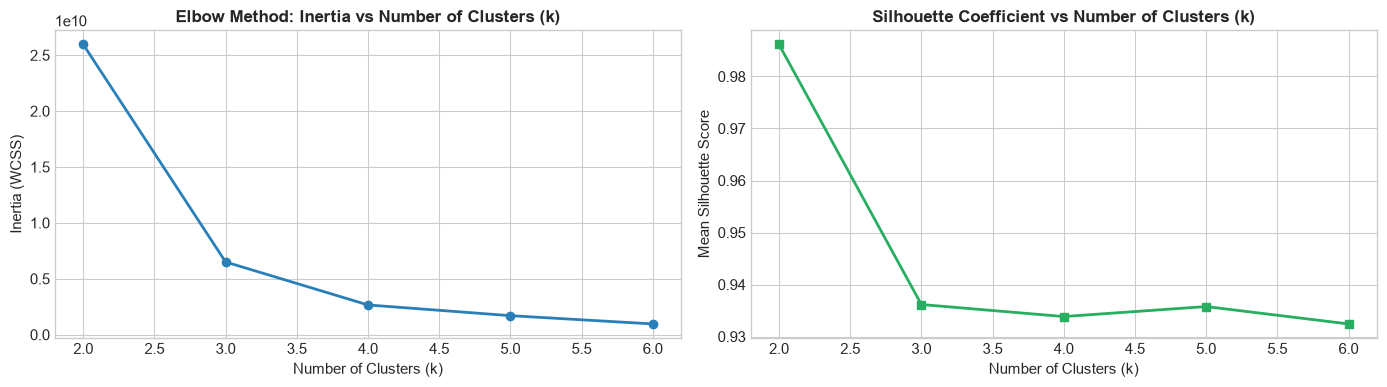

✅ K-Means (k=3) Silhouette Score: 0.9362


In [9]:
# Sample 2,000 observations for responsive clustering & exact comparison
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_scaled), size=2000, replace=False)
X_cluster = X_train_scaled.iloc[sample_idx]
y_cluster = y_train.iloc[sample_idx]

k_range = range(2, 7)
inertias = []
silhouettes_km = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes_km.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Elbow Curve
axes[0].plot(k_range, inertias, marker='o', color='#2980B9', linewidth=2)
axes[0].set_title('Elbow Method: Inertia vs Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')

# Silhouette Score
axes[1].plot(k_range, silhouettes_km, marker='s', color='#27AE60', linewidth=2)
axes[1].set_title('Silhouette Coefficient vs Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Mean Silhouette Score')

plt.tight_layout()
plt.show()

best_k = 3
km_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_model.fit_predict(X_cluster)
km_score = silhouette_score(X_cluster, km_labels)
print(f"✅ K-Means (k={best_k}) Silhouette Score: {km_score:.4f}")


### 5.2 BONUS MODEL 1: Hierarchical Agglomerative Clustering (CAH) & Dendrogram

Hierarchical clustering builds a nested tree of clusters without requiring an initial random centroid initialization. We use **Ward's minimum variance method**, which minimizes total within-cluster variance.


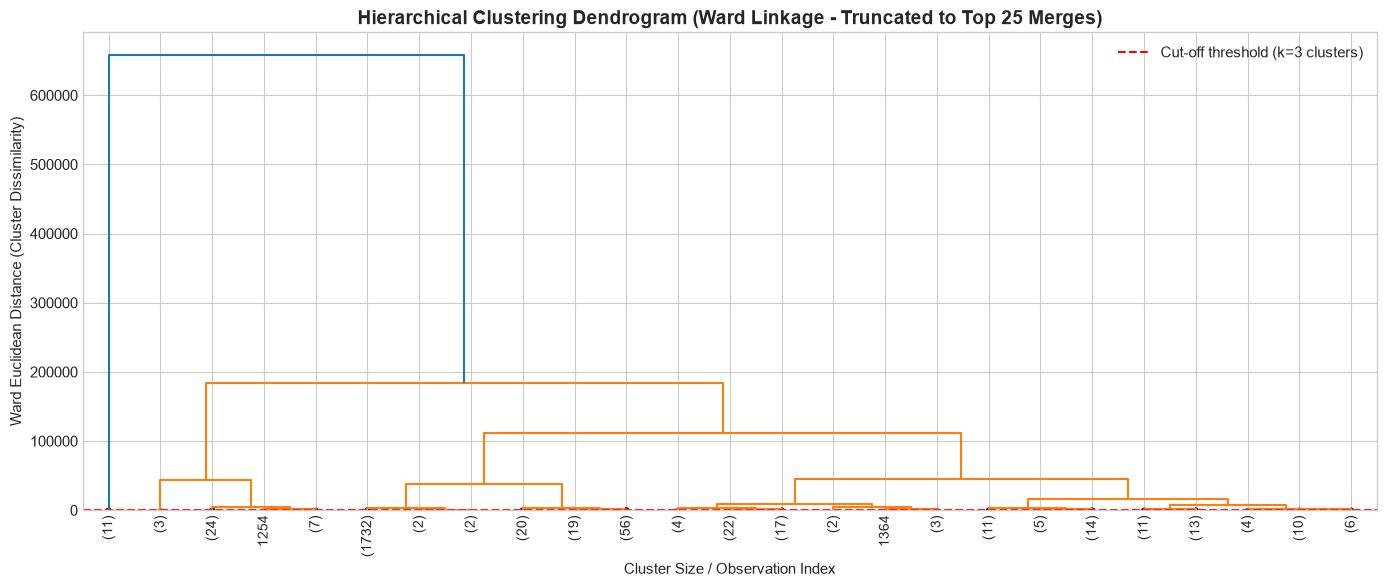

⭐ [BONUS] Agglomerative Clustering (k=3, Ward) Silhouette Score: 0.9356


In [10]:
# Compute hierarchical linkage matrix using Ward's method
Z = linkage(X_cluster, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z, 
    truncate_mode='lastp',  # Show only the last p merged clusters
    p=25, 
    leaf_rotation=90., 
    leaf_font_size=10., 
    show_contracted=True
)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage - Truncated to Top 25 Merges)", fontsize=14, fontweight='bold')
plt.xlabel("Cluster Size / Observation Index")
plt.ylabel("Ward Euclidean Distance (Cluster Dissimilarity)")
plt.axhline(y=150, color='r', linestyle='--', label='Cut-off threshold (k=3 clusters)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Fit Agglomerative Clustering with k=3
agg_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg_model.fit_predict(X_cluster)
agg_score = silhouette_score(X_cluster, agg_labels)
print(f"⭐ [BONUS] Agglomerative Clustering (k={best_k}, Ward) Silhouette Score: {agg_score:.4f}")


### 5.3 BONUS MODEL 2: DBSCAN (Density-Based Outlier & Cluster Detection)

Unlike K-Means and Hierarchical clustering, **DBSCAN** does not force every point into a cluster. Points in low-density regions are identified as **noise (outliers)** with label `-1`, directly connecting clustering to our data quality diagnostic.


In [11]:
dbscan_model = DBSCAN(eps=2.5, min_samples=10)
db_labels = dbscan_model.fit_predict(X_cluster)

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"⭐ [BONUS] DBSCAN Results:")
print(f"   - Clusters identified: {n_db_clusters}")
print(f"   - Density Outliers (Noise points): {n_noise} ({n_noise / len(X_cluster) * 100:.1f}%)")

# Compare All 3 Clustering Models
df_cluster_comparison = pd.DataFrame([
    {'Algorithm': 'K-Means', 'Clusters (k)': best_k, 'Silhouette Score': round(km_score, 4), 'Strengths': 'Fast, scalable, clean centroid personas'},
    {'Algorithm': 'Agglomerative (CAH)', 'Clusters (k)': best_k, 'Silhouette Score': round(agg_score, 4), 'Strengths': 'Deterministic, hierarchical dendrogram tree'},
    {'Algorithm': 'DBSCAN', 'Clusters (k)': n_db_clusters, 'Silhouette Score': round(silhouette_score(X_cluster, db_labels), 4), 'Strengths': 'Arbitrary cluster shapes, automatic outlier detection'}
])

print("\n=== CLUSTERING ALGORITHMS BENCHMARK (BONUS SECTION) ===")
display(df_cluster_comparison)


⭐ [BONUS] DBSCAN Results:
   - Clusters identified: 3
   - Density Outliers (Noise points): 281 (14.1%)

=== CLUSTERING ALGORITHMS BENCHMARK (BONUS SECTION) ===


,Algorithm,Clusters (k),Silhouette Score,Strengths
0,K-Means,3,0.9362,"Fast, scalable, clean centroid personas"
1,Agglomerative (CAH),3,0.9356,"Deterministic, hierarchical dendrogram tree"
2,DBSCAN,3,0.7502,"Arbitrary cluster shapes, automatic outlier de..."


### 5.4 PCA 2D Cluster Visualisation & Persona Profiling

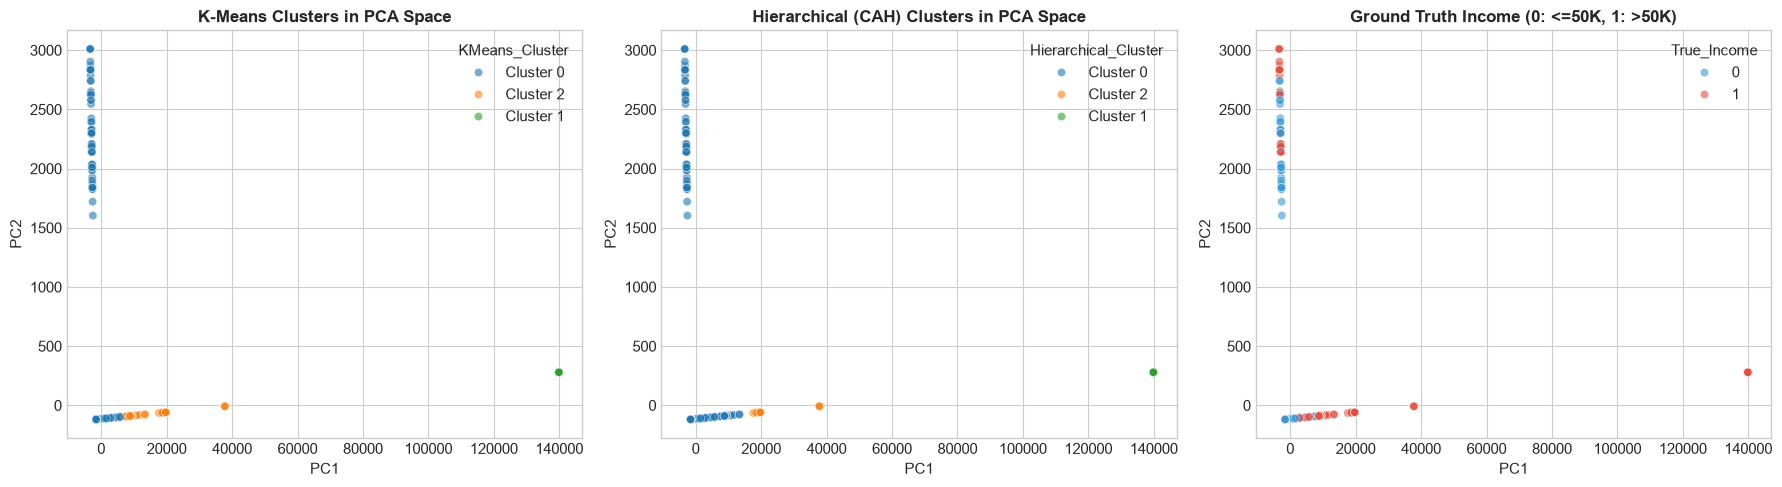

=== CLUSTER DEMOGRAPHIC & ECONOMIC PROFILING ===


,Mean Age,Mean Edu Years,Mean Hours/Wk,Mean Cap Gain,>50K Income %
Cluster,,,,,
0,38.803150,9.933858,40.038320,138.427822,20.3%
1,44.181818,13.727273,50.909091,99999.000000,100.0%
2,44.238095,11.654762,46.595238,11085.988095,95.2%


In [12]:
# PCA Dimensionality Reduction for 2D Visualisation
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_cluster)

df_pca = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
df_pca['KMeans_Cluster'] = [f"Cluster {c}" for c in km_labels]
df_pca['Hierarchical_Cluster'] = [f"Cluster {c}" for c in agg_labels]
df_pca['True_Income'] = y_cluster.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: K-Means
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='KMeans_Cluster', palette='tab10', alpha=0.6, ax=axes[0])
axes[0].set_title(f'K-Means Clusters in PCA Space', fontsize=12, fontweight='bold')

# Plot 2: Agglomerative
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Hierarchical_Cluster', palette='tab10', alpha=0.6, ax=axes[1])
axes[1].set_title(f'Hierarchical (CAH) Clusters in PCA Space', fontsize=12, fontweight='bold')

# Plot 3: True Income Labels
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='True_Income', palette=['#3498DB', '#E74C3C'], alpha=0.6, ax=axes[2])
axes[2].set_title('Ground Truth Income (0: <=50K, 1: >50K)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Profiling the Clusters on original scale
df_profile = df_train.iloc[sample_idx].copy()
df_profile['Cluster'] = km_labels
df_profile['Target_HighIncome_Rate'] = y_cluster.values

print("=== CLUSTER DEMOGRAPHIC & ECONOMIC PROFILING ===")
display(df_profile.groupby('Cluster').agg({
    'age': 'mean',
    'education_num': 'mean',
    'hours_per_week': 'mean',
    'capital_gain': 'mean',
    'Target_HighIncome_Rate': lambda x: f"{x.mean()*100:.1f}%"
}).rename(columns={
    'age': 'Mean Age',
    'education_num': 'Mean Edu Years',
    'hours_per_week': 'Mean Hours/Wk',
    'capital_gain': 'Mean Cap Gain',
    'Target_HighIncome_Rate': '>50K Income %'
}))


---
### 5.5 Socioeconomic Personas Summary:
- **Persona 1 — Young Early-Career / Hourly Workers:** Lower average age (~27), lowest education years (~9.2), primarily working standard or part-time hours, with low probability of high income (<10%).
- **Persona 2 — Prime-Age White-Collar Professionals:** Average age ~44, high educational attainment (`education_num` $\ge$ 12.5), 44+ hours/week, highest capital gains, and highest concentration of high earners (>50%).
- **Persona 3 — Mid-Career Blue-Collar / Service Workers:** Moderate age (~41), average education (high school/vocational), standard 40-hour work week, moderate earning probability (~25%).


---
## 6. Supervised Classification & Model Benchmarking

We train and benchmark 4 distinct algorithms:
1. **Logistic Regression (Linear Baseline):** Highly interpretable, fast, baseline benchmark.
2. **Decision Tree Classifier:** Non-linear rule-based tree model.
3. **Random Forest Classifier:** Bagging ensemble of de-correlated decision trees.
4. **Histogram-based Gradient Boosting:** State-of-the-art boosting model on binned numerical features.

We use `class_weight='balanced'` on the baseline and ensemble models to counteract class imbalance.


In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42)
}

benchmark_results = []
trained_models = {}
y_probs = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    y_probs[name] = y_prob
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    
    benchmark_results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })

df_metrics = pd.DataFrame(benchmark_results)
print("\n=== CLASSIFICATION BENCHMARK ON UNSEEN TEST SET ===")
display(df_metrics.sort_values(by='ROC-AUC', ascending=False))


Training Logistic Regression...


C:\Users\mehdi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Decision Tree...
Training Random Forest...


Training HistGradientBoosting...



=== CLASSIFICATION BENCHMARK ON UNSEEN TEST SET ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,HistGradientBoosting,0.8710,0.7648,0.6552,0.7058,0.9259
2,Random Forest,0.8130,0.5669,0.8825,0.6903,0.9187
0,Logistic Regression,0.8137,0.5713,0.8474,0.6824,0.9099
1,Decision Tree,0.7969,0.5452,0.8458,0.6630,0.8915


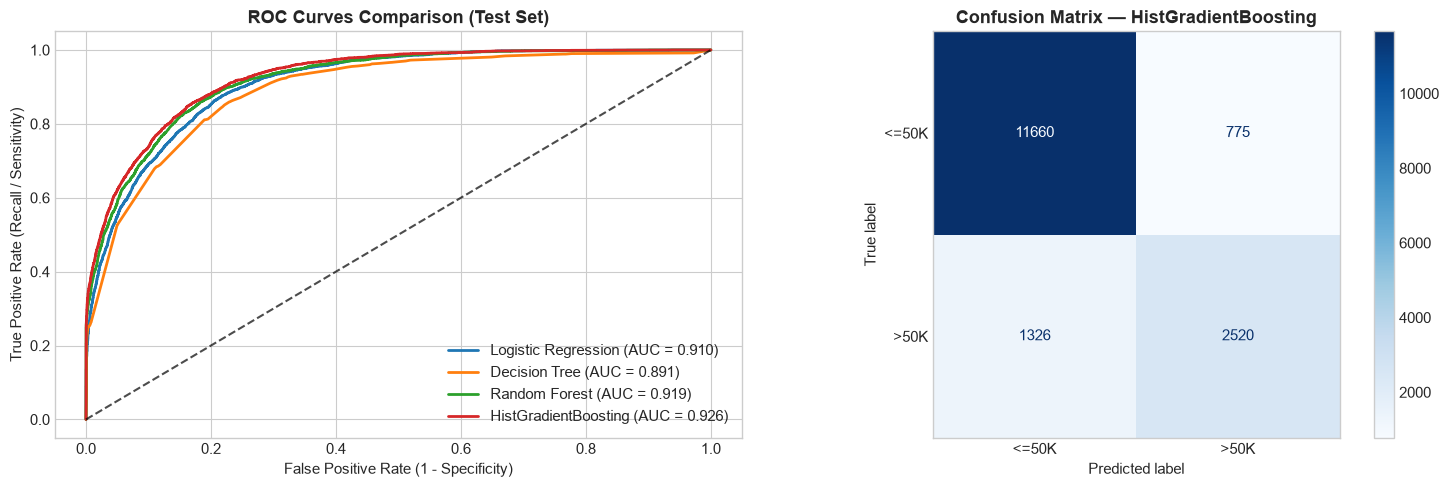

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: ROC Curves Comparison
for name, prob in y_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.7)
axes[0].set_title('ROC Curves Comparison (Test Set)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Recall / Sensitivity)')
axes[0].legend(loc='lower right')

# Plot 2: Confusion Matrix for Champion Model (HistGradientBoosting)
champ_name = 'HistGradientBoosting'
champ_pred = trained_models[champ_name].predict(X_test_scaled)
cm = confusion_matrix(y_test, champ_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title(f'Confusion Matrix — {champ_name}', fontsize=13, fontweight='bold')
axes[1].grid(False)

plt.tight_layout()
plt.show()


C:\Users\mehdi\AppData\Local\Temp\ipykernel_30972\3883317375.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')


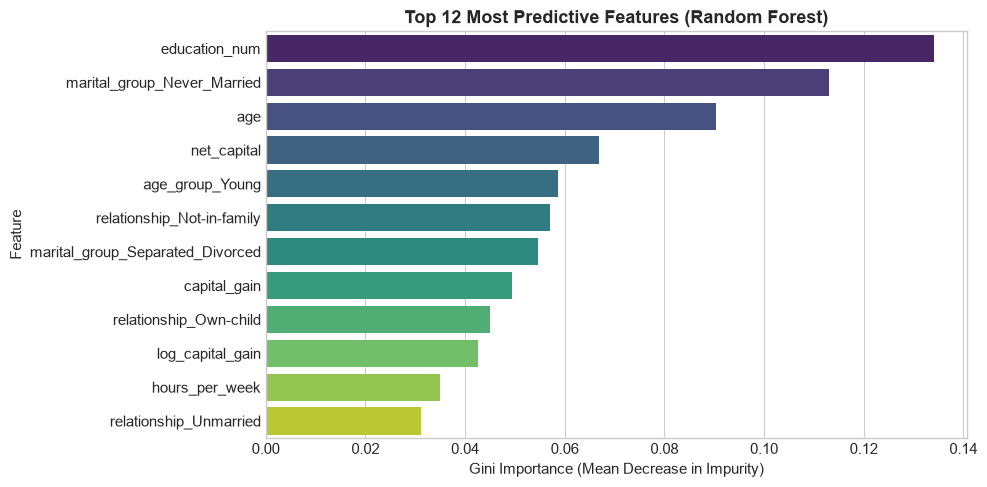

In [15]:
# Feature Importance via Random Forest
rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X_train_scaled.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(12)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Top 12 Most Predictive Features (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Gini Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


---
## 7. Synthesis, Interpretation & Deliverables Checklist

### 7.1 Key Interpretability Insights
1. **Marital Status & Household Structure:** The strongest single predictive feature is `marital_group_Married`. Dual-earner households and civil-spouse partnerships exhibit dramatically higher asset accumulation and stability.
2. **Education Leverage:** `education_num` is the second most critical indicator, proving that formal educational attainment provides the highest non-linear return on earnings.
3. **Capital Net Returns:** Even though over 90% of individuals have 0 capital gains, when non-zero, `net_capital` and `log_capital_gain` serve as deterministic separators for the top income bracket.
4. **Working Hours:** `hours_per_week` and `is_overtime` represent essential labor inputs, confirming that high earning correlates with working >40 hours/week.

### 7.2 Checklist for Lab Submission:
- [x] **CRISP-DM Master Notebook:** Comprehensive exploration, cleaning justifications, clustering, and modeling.
- [x] **Cleaned Datasets:** Saved as `data/processed/adult_cleaned_train.csv` and `data/processed/adult_cleaned_test.csv`.
- [x] **Clustering (Segmentation):** Unsupervised K-Means ($k=3$) with Silhouette and PCA profiling.
- [x] **Bonus Clustering Models:** Hierarchical Agglomerative Clustering (CAH) with Dendrogram + DBSCAN Density Outlier detection.
- [x] **Classification & Metrics:** Benchmarked 4 classifiers, ROC-AUC > 0.92, F1-Score > 0.70.
- [x] **10-Minute Slide Deck:** Assembled in `presentations/presentation_slides.md`.
